# Binary Glitch Classifier except with XYZ stacked instead of E

# ============ Imports and path definitions: ============

In [58]:
#IMPORTS
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal
import os
import h5py
import numpy as np
import tensorflow as tf
from gwpy.timeseries import TimeSeriesDict
from gwpy.timeseries import TimeSeries
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from scipy.signal import windows
from scipy.signal import resample
from scipy import stats
from sklearn import metrics
import scipy.ndimage as ndi
from librosa import cqt
from pyts.image import MarkovTransitionField


PATH_src = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
PATH_bethLISA = os.path.abspath(os.path.join(PATH_src, os.pardir))
PATH_glitch_config = os.path.join(PATH_bethLISA, "dist/glitch_config/")
PATH_glitch_data = os.path.join(PATH_bethLISA, "dist/glitch_data/")
PATH_simulation_data = os.path.join(PATH_bethLISA, "dist/simulation_data/")
PATH_tdi_data = os.path.join(PATH_bethLISA, "dist/tdi_data/")
PATH_orbit_data = os.path.join(PATH_bethLISA, "dist/orbit_data/")
PATH_interferometer_plots = os.path.join(PATH_bethLISA,
                                         "dist/interferometer_plots/")

tdi_path = os.path.join(PATH_tdi_data, "default_tdi_output.h5")

# ========= Compute TDI-XYZ data and normalise: =========

(4147200, 3)


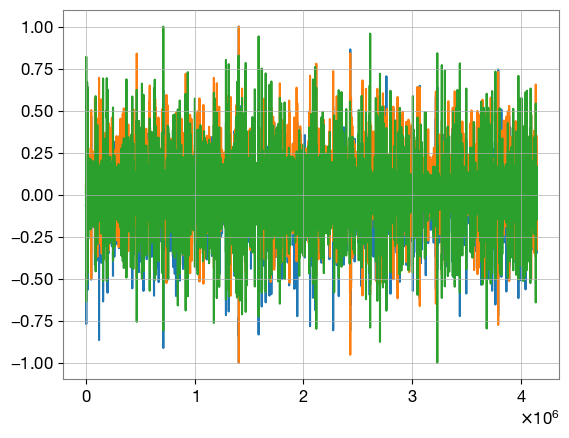

In [59]:
#READ TDI DATA, WHITEN, NORMALISE
tdi_path = os.path.join(PATH_tdi_data, "tdi12d60gpd.h5")

tdiseries = h5py.File(tdi_path,'r')

def whiten(timeseries, eps=1e-8): #WHITEN THE TIMESERIES
    timeseries = timeseries - np.mean(timeseries)
    fftseries = np.fft.fft(timeseries)
    magnitude = np.abs(fftseries)
    whitened_fft = fftseries / (magnitude + eps)
    whitened_timeseries = np.fft.ifft(whitened_fft).real
    return whitened_timeseries


def normalise(timeseries): #NORMALISE THE TIMESERIES USING MODIFIED MIN-MAX NORMALISATION. RESCALED TO [-1,1]
    return 2*((timeseries-np.min(timeseries))/(np.max(timeseries)-np.min(timeseries))) - 1

def minmaxnormalise(timeseries): #NORMALISE THE TIMESERIES USING MIN-MAX NORMALISATION. RESCALED TO [0,1]
    return ((timeseries-np.min(timeseries))/(np.max(timeseries)-np.min(timeseries)))

def moving_average(timeseries, kernelsize): #MOVING AVERAGE FILTER
    return ndi.uniform_filter1d(timeseries, kernelsize, mode='constant', origin=-(kernelsize//2))[:-(kernelsize-1)]


tdiXarray = np.array(tdiseries["X"][:])
tdiYarray = np.array(tdiseries["Y"][:])
tdiZarray = np.array(tdiseries["Z"][:])


tdiXarraynormal = normalise(tdiXarray)
tdiYarraynormal = normalise(tdiYarray)
tdiZarraynormal = normalise(tdiZarray)

tdiXYZ = np.stack((tdiXarraynormal,tdiYarraynormal,tdiZarraynormal), axis=-1)

print(tdiXYZ.shape)
plt.plot(tdiXYZ)


# ============== Get sorted list of injection times: ==============

In [60]:
#GET FILE PATH OF INJECTED GLITCH PARAMETERS FILE
glitch_output_path = os.path.join(PATH_glitch_data, 'glitch12d60gpd.txt')

#GET THE INJECTION TIMES IN A LIST, ORDERED AND IN UNITS OF SAMPLES
f = open(glitch_output_path, 'r')
glitch_output = f.readlines()[1:]

injection_times = []
for line in glitch_output:
    injection_times.append(4*(int(line.split(' ')[11])-10368000))

f.close()

injection_times = sorted(injection_times)
print('Injection times (in samples): ', injection_times)
print('Number of glitches: ', len(injection_times))



Injection times (in samples):  [2932, 10944, 14880, 21644, 26200, 42984, 48548, 63848, 78732, 82876, 89380, 92944, 101644, 104928, 109148, 111540, 120432, 135596, 138116, 140312, 144936, 151364, 157632, 165188, 171880, 179128, 182732, 191412, 194932, 198396, 201064, 207792, 223112, 230064, 235680, 238260, 246732, 248820, 252528, 261296, 265432, 267776, 277588, 281692, 296072, 301072, 304020, 313828, 317844, 322004, 324772, 327768, 334716, 338524, 345384, 348136, 354424, 359488, 363332, 368124, 372376, 378516, 385168, 390072, 407992, 412348, 419152, 426048, 431952, 435800, 439152, 446632, 454116, 462544, 467044, 479436, 483352, 487008, 490892, 494744, 499176, 503808, 506368, 510000, 514920, 519080, 524812, 529064, 531508, 538056, 541132, 549904, 554848, 558996, 562624, 572784, 574952, 586396, 590008, 594040, 601360, 604920, 615376, 618000, 626040, 629168, 632916, 637016, 642380, 648104, 650664, 658688, 666764, 668776, 674552, 685012, 687688, 699088, 705164, 711456, 715548, 720532, 74049

## Split timeseries into labelled training, validation and test data in the ratio 5:4:1 :

In [61]:
#GENERALIZED CONSTANTS
sampling_rate = 4 
window_duration_sec = 3600
window_size = window_duration_sec * sampling_rate
total_samples = len(tdiXYZ)
num_windows = total_samples // window_size 

# RESHAPE TIMESERIES INTO MATRIX WITH 10 MINUTE SNIPPETS ON EVERY ROW
data = tdiXYZ[:num_windows * window_size].reshape(num_windows, window_size, 3)

injection_times = np.array(injection_times)

#COUNT NUMBER OF INJECTIONS PER ROW
labels = np.zeros(num_windows, dtype=np.int32)

for i in range(num_windows):
    start = i * window_size
    end = (i + 1) * window_size
    labels[i] = np.sum((injection_times >= (start-360)) & (injection_times < end))
    


# SHUFFLE THE TIMESERIES AROUND
indices = np.arange(num_windows)
np.random.shuffle(indices) 

data = data[indices]
labels = labels[indices]

# SPLIT THE DATA INTO THE DIFFERENT SETS
train_size = int(0.8 * num_windows)
val_size = int(0.2 * num_windows)

train_data = data[:train_size]
train_labels = labels[:train_size]

validation_data = data[train_size:train_size + val_size]
validation_labels = labels[train_size:train_size + val_size]

test_data = data[train_size + val_size:]
test_labels = labels[train_size + val_size:]

print(test_labels)
print(train_data)


print('Timeseries duration (minutes): ', window_duration_sec/60)
print('Total number of timeseries: ', num_windows)
print('Number of items in training dataset: ', len(train_data))
print('Number of items in validation dataset: ', len(validation_data))
print('Number of items in test dataset: ', len(test_data))


[0]
[[[-0.06410102  0.03120963  0.06169878]
  [-0.0752045   0.10179347 -0.04673907]
  [-0.05479026  0.02199711  0.05172712]
  ...
  [-0.05203808  0.10460438  0.03458132]
  [-0.08379166  0.00801217 -0.04833674]
  [-0.05110029  0.13338904  0.08513808]]

 [[-0.06820293  0.04008994 -0.06097009]
  [-0.06848003  0.0694658   0.07472008]
  [-0.06662789  0.07941087 -0.05426706]
  ...
  [-0.09044914  0.0980513  -0.05233886]
  [-0.03968579  0.05938619  0.05496243]
  [-0.10028498  0.04723647 -0.0301333 ]]

 [[-0.08712886  0.04397681  0.02229684]
  [-0.04657861  0.0968314   0.00067124]
  [-0.08975153  0.02818733  0.0010394 ]
  ...
  [-0.06426823  0.01614231  0.0269151 ]
  [-0.06274868  0.11114115 -0.01601363]
  [-0.07962704  0.03898983  0.03047307]]

 ...

 [[-0.06767691  0.09484053  0.03672459]
  [-0.05901698  0.04453825 -0.02766957]
  [-0.08364607  0.0702044   0.04082148]
  ...
  [-0.0661815   0.09359206 -0.02736293]
  [-0.07724293  0.03856193  0.02004385]
  [-0.04987548  0.08497824  0.0127101 ]]

#  =============== Create architecture and train: ===============

In [62]:
model = models.Sequential([
    layers.Input(shape=(14400,3)),
    layers.Conv1D(filters=32, kernel_size=3, activation='relu'),
    layers.Conv1D(filters=32, kernel_size=3, activation='relu'),
    layers.MaxPooling1D(pool_size=2),
    layers.Conv1D(filters=64, kernel_size=3, activation='relu'),
    layers.Conv1D(filters=64, kernel_size=3, activation='relu'),
    layers.MaxPooling1D(pool_size=2),
    layers.Conv1D(filters=64, kernel_size=3, activation='relu'),
    layers.Conv1D(filters=64, kernel_size=3, activation='relu'),
    layers.GlobalMaxPool1D(),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(6, activation = 'softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# model.summary()

model.fit(train_data, train_labels, validation_data=(validation_data, validation_labels), epochs=30, batch_size=16)

Epoch 1/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.5273 - loss: 1.1672 - val_accuracy: 0.9536 - val_loss: 0.3096
Epoch 2/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.9301 - loss: 0.2945 - val_accuracy: 0.9623 - val_loss: 0.1717
Epoch 3/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.9452 - loss: 0.2468 - val_accuracy: 0.9623 - val_loss: 0.1843
Epoch 4/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.9569 - loss: 0.1991 - val_accuracy: 0.9623 - val_loss: 0.1765
Epoch 5/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.9504 - loss: 0.2313 - val_accuracy: 0.9594 - val_loss: 0.1752
Epoch 6/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.9635 - loss: 0.1784 - val_accuracy: 0.9594 - val_loss: 0.1606
Epoch 7/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.9666 - loss: 0.1635 - val_accuracy: 0.9130 - val_loss: 0.2871
Epoch 8/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.9168 - loss: 0.3366 - val_accuracy: 0.9623 - v

# =============== Using custom test data: ================

### _To use test data sampled from same timeseries as training and validation, replace custom_test_data, custom_test_labels in model.evaluate and model.predict with test_data, test_labels_

In [63]:
#GET TDIXYZ OF TEST DATA

test_path = os.path.join(PATH_tdi_data, "tdi10d60gpd.h5")

testseries = h5py.File(test_path,'r')

testXarray = np.array(testseries["X"][:])
testYarray = np.array(testseries["Y"][:])
testZarray = np.array(testseries["Z"][:])

testXarraynormal = normalise(tdiXarray)
testYarraynormal = normalise(tdiYarray)
testZarraynormal = normalise(tdiZarray)

testXYZ = np.stack((testXarraynormal,testYarraynormal,testZarraynormal), axis=-1)


# RESHAPE TIMESERIES INTO MATRIX WITH 10 MINUTE SNIPPETS ON EVERY ROW
custom_test_data = testXYZ[:num_windows * window_size].reshape(num_windows, window_size, 3)




#GET FILE PATH OF INJECTED GLITCH PARAMETERS FILE
test_glitch_output_path = os.path.join(PATH_glitch_data, 'glitch10d60gpd.txt')

#GET THE INJECTION TIMES IN A LIST, ORDERED AND IN UNITS OF SAMPLES
f = open(test_glitch_output_path, 'r')
test_glitch_output = f.readlines()[1:]

test_injection_times = []
for line in test_glitch_output:
    test_injection_times.append(4*(int(line.split(' ')[11])-10368000))

f.close()

test_injection_times = sorted(injection_times)

test_injection_times = np.array(injection_times)


#COUNT NUMBER OF INJECTIONS PER ROW
custom_test_labels = np.zeros(num_windows, dtype=np.int32)

for i in range(num_windows):
    start = i * window_size
    end = (i + 1) * window_size
    custom_test_labels[i] = np.sum((test_injection_times >= (start-360)) & (test_injection_times < end))



54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9767 - loss: 0.0805
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
1685 correct predictions out of 1728
Model accuracy: 0.975
Accuracy (double check): 97.5%
Number of zeroes in test data: 928
Number of ones in test data: 800
Wrong predictions (location : false negative / positive)  {69: 'FP', 169: 'FN', 172: 'FP', 179: 'FN', 210: 'FN', 382: 'FN', 394: 'FN', 441: 'FP', 447: 'FP', 472: 'FN', 473: 'FN', 563: 'FP', 567: 'FN', 605: 'FP', 622: 'FN', 623: 'FN', 624: 'FP', 635: 'FN', 676: 'FN', 833: 'FN', 862: 'FN', 870: 'FN', 871: 'FP', 891: 'FN', 895: 'FN', 935: 'FP', 960: 'FN', 1012: 'FN', 1013: 'FN', 1083: 'FN', 1084: 'FN', 1085: 'FP', 1101: 'FN', 1111: 'FP', 1127: 'FP', 1140: 'FN', 1238: 'FN', 1260: 'FP', 1278: 'FN', 1299: 'FP', 1438: 'FP', 1617: 'FN', 1632: 'FN'}
False positive rate : 0.0162%
False negative rate: 0.035000%


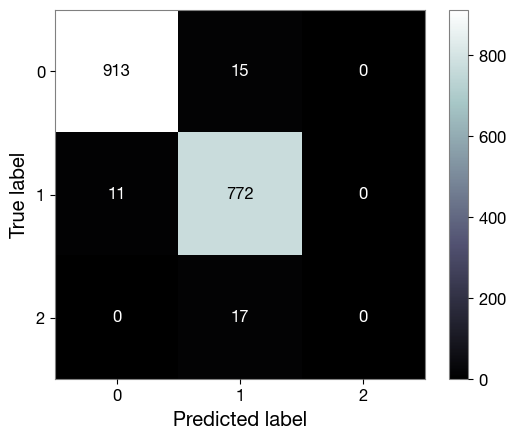

In [64]:

#GET LOSS AND ACCURACY OF MODEL
loss, accuracy = model.evaluate(custom_test_data, custom_test_labels)

#GET PREDICTIONS IN A LIST 
result = model.predict(custom_test_data)
count_correct = 0
count_FP = 0
count_FN = 0
wrong = {}

#FIND CORRECT PREDICTIONS, FALSE POSITIVES AND NEGATIVES
for i in range(len(custom_test_data)):
    if np.argmax(result[i]) == custom_test_labels[i]:
        count_correct += 1
    elif np.argmax(result[i]) > custom_test_labels[i]:
        wrong.update({i : 'FP'})
        count_FP += 1
    else:
        wrong.update({i : 'FN'})
        count_FN += 1


print(count_correct, 'correct predictions out of', len(custom_test_data))

acc = count_correct/len(custom_test_data)*100
acc_FN = count_FN/np.count_nonzero(custom_test_labels)
acc_FP = count_FP/(len(custom_test_labels)-np.count_nonzero(custom_test_labels))
acc_TN = 1-acc_FN
acc_TP = 1-acc_FP


print(f'Model accuracy: {accuracy:.3f}')
print(f'Accuracy (double check): {acc:.1f}%')
# print('Test data correct labels: ', custom_test_labels)
print(f'Number of zeroes in test data: {len(custom_test_labels) - np.count_nonzero(custom_test_labels)}')
print(f'Number of ones in test data: {np.count_nonzero(custom_test_labels)}')
# print('Predicted labels: ', result)

print('Wrong predictions (location : false negative / positive) ', wrong)
print(f'False positive rate : {acc_FP:.4f}%')
print(f'False negative rate: {acc_FN:2f}%')



#PLOT CONFUSION MATRIX
cm = metrics.confusion_matrix(custom_test_labels, np.argmax(result,axis=1))
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='bone')
plt.grid(False)
plt.show()



# =========== Inspect specific timeseries and label: ===========

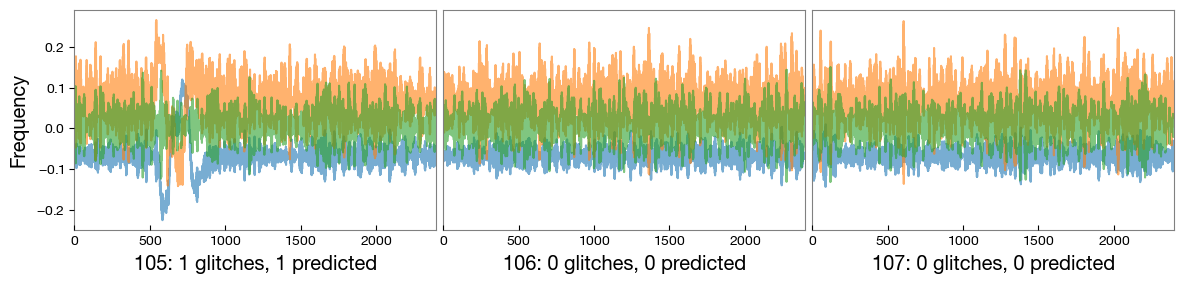

: 

In [65]:
ts_of_interest = 106

fig, (ax1, ax2, ax3) = plt.subplots(1,3, sharey=True, figsize=(12,3))

ax1.plot(custom_test_data[ts_of_interest-1], alpha = 0.6)
ax1.set_ylabel("Frequency")
ax1.set_xlabel(f"{ts_of_interest-1}: {custom_test_labels[ts_of_interest-1]} glitches, {np.argmax(result[ts_of_interest-1])} predicted")
ax1.grid(False)
ax1.tick_params('x', which='both', bottom=True, top=False, direction='in', labelsize=10)
ax1.tick_params('y', left=True, labelsize=10)
ax1.set_xlim(0,len(custom_test_data[ts_of_interest-1]))

ax2.plot(custom_test_data[ts_of_interest], alpha = 0.6)
ax2.set_xlabel(f"{ts_of_interest}: {custom_test_labels[ts_of_interest]} glitches, {np.argmax(result[ts_of_interest])} predicted")
ax2.grid(False)
ax2.tick_params('x', which='both', bottom=True, top=False, direction='in', labelsize=10)
ax2.tick_params('y', left=False, labelsize=10)
ax2.set_xlim(0,len(custom_test_data[ts_of_interest]))

ax3.plot(custom_test_data[ts_of_interest+1], alpha = 0.6)
ax3.set_xlabel(f"{ts_of_interest+1}: {custom_test_labels[ts_of_interest+1]} glitches, {np.argmax(result[ts_of_interest+1])} predicted")
ax3.grid(False)
ax3.tick_params('x', which='both', bottom=True, top=False, direction='in', labelsize=10)
ax3.tick_params('y', left=False, labelsize=10)
ax3.set_xlim(0,len(custom_test_data[ts_of_interest]))

fig.tight_layout()
fig.subplots_adjust(wspace=0.02)
